In [1]:
#Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

In [2]:
train_df = pd.read_csv("KDDTrain+.txt", header=None)
test_df = pd.read_csv("KDDTest+.txt", header=None)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (125973, 43)
Test shape: (22544, 43)


In [3]:
#assigning columns

columns = (['duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment'
,'urgent','hot','num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root'
,'num_file_creations','num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login'
,'count','srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate'
,'diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count','dst_host_same_srv_rate'
,'dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate'
,'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','attack','level'])

train_df.columns = columns
test_df.columns = columns

In [4]:
#attack ---> 0/1
train_df['attack'] = train_df['attack'].apply(lambda x: 0 if x == 'normal' else 1)
test_df['attack'] = test_df['attack'].apply(lambda x: 0 if x == 'normal' else 1)

In [5]:
#check class distribution 
print("Train Class Distribution:")
print(train_df["attack"].value_counts())

print("\nTest Class Distribution:")
print(test_df["attack"].value_counts())

Train Class Distribution:
attack
0    67343
1    58630
Name: count, dtype: int64

Test Class Distribution:
attack
1    12833
0     9711
Name: count, dtype: int64


In [6]:
train_df.drop('level', axis=1, inplace=True)
test_df.drop('level', axis=1, inplace=True)

In [7]:
print("train df")
train_df.head()

train df


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,0
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,0
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,1
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,0
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0


In [8]:
print("test df")
test_df.head()

test df


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack
0,0,tcp,private,REJ,0,0,0,0,0,0,...,10,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00,1
1,0,tcp,private,REJ,0,0,0,0,0,0,...,1,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00,1
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,86,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00,0
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,57,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00,1
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,86,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71,1


In [9]:
# ================================
#Separate Features & Target
# ================================

X_train = train_df.drop("attack", axis=1)
y_train = train_df["attack"]

X_test = test_df.drop("attack", axis=1)
y_test = test_df["attack"]

In [10]:
def unique_values(df, columns):
    for col in columns:
        print(f"\n{'='*10} {col} {'='*10}")
        print(f"Total Unique: {df[col].nunique()}")
        print(df[col].value_counts())

In [11]:
cat_features = train_df.select_dtypes(include='object').columns
unique_values(train_df, cat_features)


========== protocol_type ==========
Total Unique: 3
protocol_type
tcp     102689
udp      14993
icmp      8291
Name: count, dtype: int64

========== service ==========
Total Unique: 70
service
http         40338
private      21853
domain_u      9043
smtp          7313
ftp_data      6860
             ...  
tftp_u           3
http_8001        2
aol              2
harvest          2
http_2784        1
Name: count, Length: 70, dtype: int64

========== flag ==========
Total Unique: 11
flag
SF        74945
S0        34851
REJ       11233
RSTR       2421
RSTO       1562
S1          365
SH          271
S2          127
RSTOS0      103
S3           49
OTH          46
Name: count, dtype: int64


C:\Users\VICTUS\AppData\Local\Temp\ipykernel_6660\3294552790.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = train_df.select_dtypes(include='object').columns


### EDA 

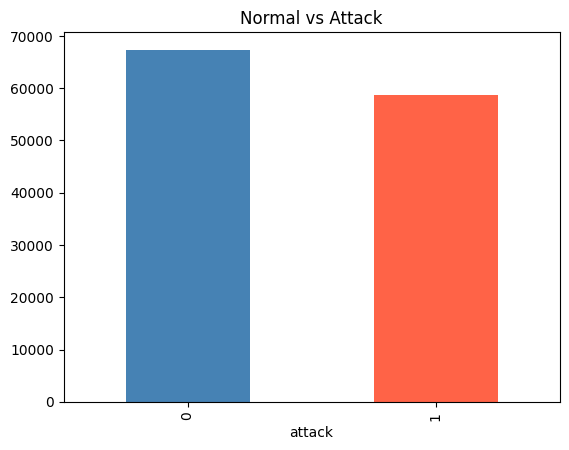

In [12]:
# Class Distribution
train_df['attack'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('Normal vs Attack'); plt.show()

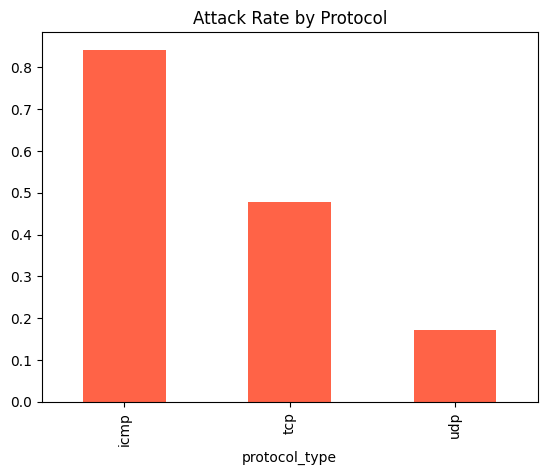

In [13]:
# Protocol Attack Rate
train_df.groupby('protocol_type')['attack'].mean().plot(kind='bar', color='tomato')
plt.title('Attack Rate by Protocol'); plt.show()

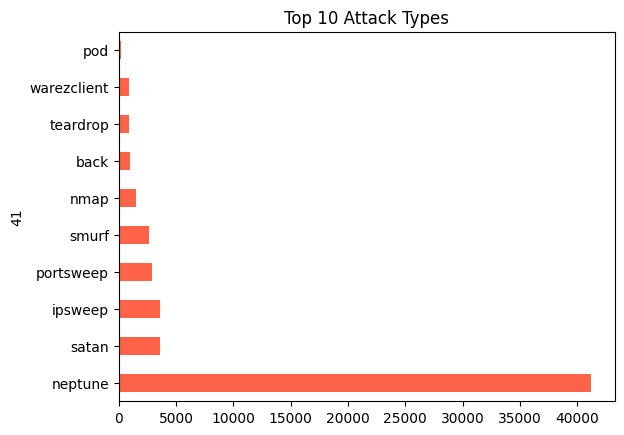

In [14]:
# Top 10 Attack Types (original labels)
train_raw = pd.read_csv('KDDTrain+.txt', header=None)
# (assign columns same as before, then:)
train_raw[train_raw[41] != 'normal'][41].value_counts().head(10).plot(kind='barh', color='tomato')
plt.title('Top 10 Attack Types'); plt.show()

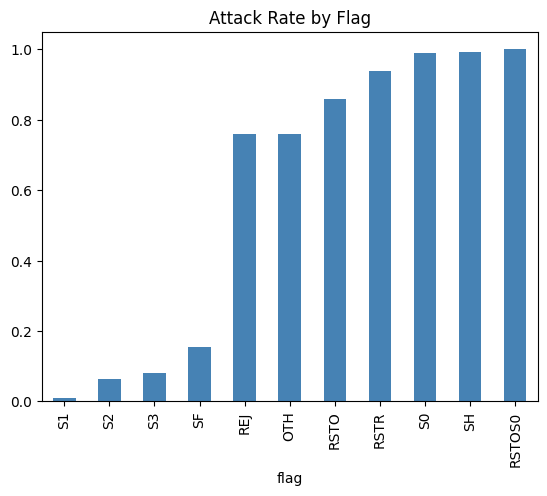

In [15]:
# Flag vs Attack Rate
train_df.groupby('flag')['attack'].mean().sort_values().plot(kind='bar', color='steelblue')
plt.title('Attack Rate by Flag'); plt.show()

### feature engineering

In [16]:
'''from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ["protocol_type", "service", "flag"]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough',   # keep numeric columns as they are
    verbose_feature_names_out=False #to remove remaineder_ from output of imp features
)

# Fit only on training data
X_train = preprocessor.fit_transform(X_train)

# Transform test data
X_test = preprocessor.transform(X_test)'''

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import category_encoders as ce  # Import the specialized encoder

# Split your columns by their "size" (cardinality)
low_cardinality_cols = ["protocol_type", "flag"] # Few categories
high_cardinality_cols = ["service"]              # ~70 categories

preprocessor = ColumnTransformer(
    transformers=[
        # Standard OHE for small categories
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), low_cardinality_cols),
        
        # Binary Encoding for the 70-category 'service' column
        # This reduces 70 columns down to just 7 columns!
        ('bin', ce.BinaryEncoder(), high_cardinality_cols)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

# Fit and transform as usual
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [17]:
from sklearn.feature_selection import mutual_info_classif

# Step 1: compute raw MI scores from the encoded X_train
mi_scores_raw = mutual_info_classif(X_train, y_train)

# Step 2: get feature names (X_train is a NumPy array after ColumnTransformer)
feature_names = preprocessor.get_feature_names_out()

# Step 3: wrap into Series with correct index
mi_scores = pd.Series(mi_scores_raw, index=feature_names)
mi_scores = mi_scores.sort_values(ascending=False)

mi_scores.head(20)

src_bytes                      0.566344
dst_bytes                      0.442314
same_srv_rate                  0.367284
diff_srv_rate                  0.358963
flag_SF                        0.341655
dst_host_srv_count             0.336828
dst_host_same_srv_rate         0.312035
logged_in                      0.292092
dst_host_serror_rate           0.286033
dst_host_diff_srv_rate         0.284672
dst_host_srv_serror_rate       0.282206
serror_rate                    0.279095
srv_serror_rate                0.267212
flag_S0                        0.263841
count                          0.263282
service_5                      0.211809
dst_host_srv_diff_host_rate    0.187456
service_6                      0.149634
dst_host_count                 0.145808
service_4                      0.139373
dtype: float64

In [18]:
# if we comment this out, model will not use top features
'''top_feature_names = mi_scores.head(25).index.tolist()
top_feature_indices = [list(feature_names).index(f) for f in top_feature_names]
X_train = X_train[:, top_feature_indices]
X_test = X_test[:, top_feature_indices]'''

'top_feature_names = mi_scores.head(25).index.tolist()\ntop_feature_indices = [list(feature_names).index(f) for f in top_feature_names]\nX_train = X_train[:, top_feature_indices]\nX_test = X_test[:, top_feature_indices]'

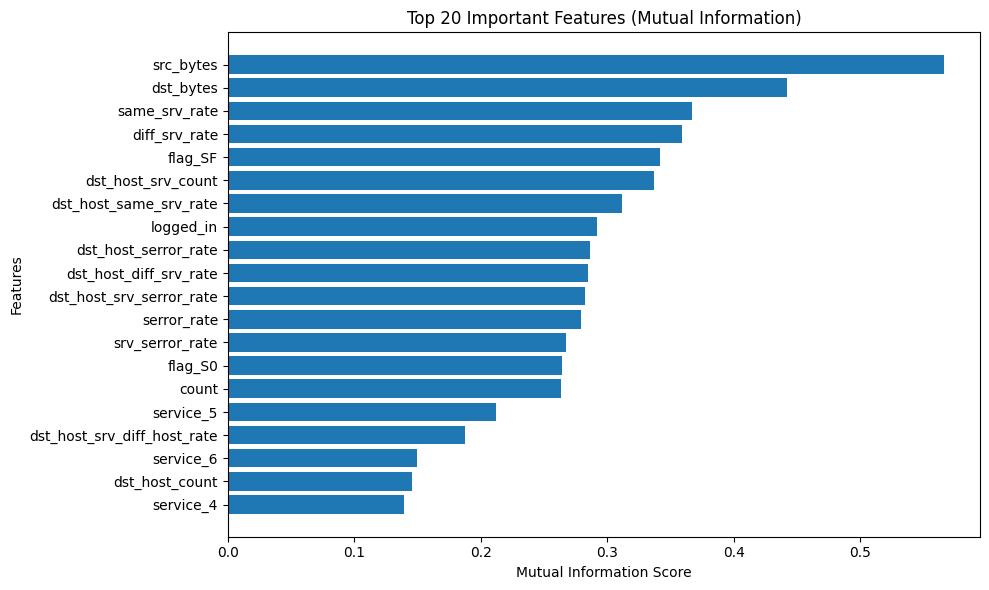

In [19]:
import matplotlib.pyplot as plt

# Select top 20 features
top_n = 20
top_features = mi_scores.head(top_n)

# Plot
plt.figure(figsize=(10,6))
plt.barh(top_features.index, top_features.values)

plt.gca().invert_yaxis()   # Highest score on top
plt.title("Top 20 Important Features (Mutual Information)")
plt.xlabel("Mutual Information Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### using SMOTE

In [21]:
# ================================
#Apply SMOTE (NOW it will work)
# ================================
from imblearn.over_sampling import SMOTE
import numpy as np

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE:", np.bincount(y_train_sm))

Before SMOTE: [67343 58630]
After SMOTE: [67343 67343]


### Model Building

In [22]:
#Baseline RF
'''from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix, classification_report

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,              # prevents overfitting
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',   
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_sm, y_train_sm)
rf_pred = rf.predict(X_test)

print("=== Random Forest Results ===")
print("Accuracy :", round(accuracy_score(y_test, rf_pred), 4))
print("Recall   :", round(recall_score(y_test, rf_pred), 4))
print("F1       :", round(f1_score(y_test, rf_pred), 4))
print("\nClassification Report:\n", classification_report(y_test, rf_pred, target_names=['Normal', 'Attack']))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))'''

'from sklearn.ensemble import RandomForestClassifier\nfrom sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix, classification_report\n\nrf = RandomForestClassifier(\n    n_estimators=200,\n    max_depth=20,              # prevents overfitting\n    min_samples_split=2,\n    min_samples_leaf=1,\n    class_weight=\'balanced\',   \n    random_state=42,\n    n_jobs=-1\n)\n\nrf.fit(X_train_sm, y_train_sm)\nrf_pred = rf.predict(X_test)\n\nprint("=== Random Forest Results ===")\nprint("Accuracy :", round(accuracy_score(y_test, rf_pred), 4))\nprint("Recall   :", round(recall_score(y_test, rf_pred), 4))\nprint("F1       :", round(f1_score(y_test, rf_pred), 4))\nprint("\nClassification Report:\n", classification_report(y_test, rf_pred, target_names=[\'Normal\', \'Attack\']))\nprint("Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))'

In [23]:
# tuned with thresehold = 0.3 
'''import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix, classification_report

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced', 
    random_state=42,
    n_jobs=-1
)

# 2. Fit on your SMOTE data
rf.fit(X_train_sm, y_train_sm)

# 3. Threshold Tuning for 80%+ Recall
# Instead of rf.predict(), we use probabilities    # [:, 1] gets the probability of the 'Attack' class
y_probs = rf.predict_proba(X_test)[:, 1]
custom_threshold = 0.3
rf_pred_tuned = (y_probs >= custom_threshold).astype(int)

# 4. Print results
print(f"=== Tuned Random Forest Results (Threshold: {custom_threshold}) ===")
print("Accuracy :", round(accuracy_score(y_test, rf_pred_tuned), 4))
print("Recall   :", round(recall_score(y_test, rf_pred_tuned), 4))
print("F1       :", round(f1_score(y_test, rf_pred_tuned), 4))
print("\nClassification Report:\n", classification_report(y_test, rf_pred_tuned, target_names=['Normal', 'Attack']))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_pred_tuned))'''

'import numpy as np\nimport pandas as pd\nfrom sklearn.ensemble import RandomForestClassifier\nfrom sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix, classification_report\n\nrf = RandomForestClassifier(\n    n_estimators=200,\n    max_depth=20,\n    min_samples_split=2,\n    min_samples_leaf=1,\n    class_weight=\'balanced\', \n    random_state=42,\n    n_jobs=-1\n)\n\n# 2. Fit on your SMOTE data\nrf.fit(X_train_sm, y_train_sm)\n\n# 3. Threshold Tuning for 80%+ Recall\n# Instead of rf.predict(), we use probabilities    # [:, 1] gets the probability of the \'Attack\' class\ny_probs = rf.predict_proba(X_test)[:, 1]\ncustom_threshold = 0.3\nrf_pred_tuned = (y_probs >= custom_threshold).astype(int)\n\n# 4. Print results\nprint(f"=== Tuned Random Forest Results (Threshold: {custom_threshold}) ===")\nprint("Accuracy :", round(accuracy_score(y_test, rf_pred_tuned), 4))\nprint("Recall   :", round(recall_score(y_test, rf_pred_tuned), 4))\nprint("F1       :", roun

In [24]:
'''
# This is used as the final model for project
# tuned with thresehold = 0.2 
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix, classification_report

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced', 
    random_state=42,
    n_jobs=-1
)

# 2. Fit on your SMOTE data
rf.fit(X_train_sm, y_train_sm)

# 3. Threshold Tuning for 80%+ Recall
# Instead of rf.predict(), we use probabilities    # [:, 1] gets the probability of the 'Attack' class
y_probs = rf.predict_proba(X_test)[:, 1]
custom_threshold = 0.2
rf_pred_tuned = (y_probs >= custom_threshold).astype(int)

# 4. Print results
print(f"=== Tuned Random Forest Results (Threshold: {custom_threshold}) ===")
print("Accuracy :", round(accuracy_score(y_test, rf_pred_tuned), 4))
print("Recall   :", round(recall_score(y_test, rf_pred_tuned), 4))
print("F1       :", round(f1_score(y_test, rf_pred_tuned), 4))
print("\nClassification Report:\n", classification_report(y_test, rf_pred_tuned, target_names=['Normal', 'Attack']))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_pred_tuned))'''

'\n# This is used as the final model for project\n# tuned with thresehold = 0.2 \nimport numpy as np\nimport pandas as pd\nfrom sklearn.ensemble import RandomForestClassifier\nfrom sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix, classification_report\n\nrf = RandomForestClassifier(\n    n_estimators=200,\n    max_depth=20,\n    min_samples_split=2,\n    min_samples_leaf=1,\n    class_weight=\'balanced\', \n    random_state=42,\n    n_jobs=-1\n)\n\n# 2. Fit on your SMOTE data\nrf.fit(X_train_sm, y_train_sm)\n\n# 3. Threshold Tuning for 80%+ Recall\n# Instead of rf.predict(), we use probabilities    # [:, 1] gets the probability of the \'Attack\' class\ny_probs = rf.predict_proba(X_test)[:, 1]\ncustom_threshold = 0.2\nrf_pred_tuned = (y_probs >= custom_threshold).astype(int)\n\n# 4. Print results\nprint(f"=== Tuned Random Forest Results (Threshold: {custom_threshold}) ===")\nprint("Accuracy :", round(accuracy_score(y_test, rf_pred_tuned), 4))\nprint("Reca

In [25]:
# tuned with threshold = 0.2 
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix, classification_report

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced', 
    random_state=42,
    n_jobs=-1
)

# 2. Fit on your SMOTE data
rf.fit(X_train_sm, y_train_sm)

# 3. Threshold Tuning
y_probs = rf.predict_proba(X_test)[:, 1]
custom_threshold = 0.2
rf_pred_tuned = (y_probs >= custom_threshold).astype(int)

# 4. Print results
print(f"=== Tuned Random Forest Results (Threshold: {custom_threshold}) ===")
print("Accuracy :", round(accuracy_score(y_test, rf_pred_tuned), 4))
print("Recall   :", round(recall_score(y_test, rf_pred_tuned), 4))
print("F1       :", round(f1_score(y_test, rf_pred_tuned), 4))
print("\nClassification Report:\n", classification_report(y_test, rf_pred_tuned, target_names=['Normal', 'Attack']))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_pred_tuned))

#5. THIS SECTION (Probability Output)
print("\nSample Predictions with Probability:")

for i in range(10):
    actual = "Attack" if y_test.iloc[i] == 1 else "Normal"
    predicted = "Attack" if rf_pred_tuned[i] == 1 else "Normal"
    prob = round(y_probs[i] * 100, 2)

    print(f"Actual: {actual} | Predicted: {predicted} | Attack Prob: {prob}%")

=== Tuned Random Forest Results (Threshold: 0.2) ===
Accuracy : 0.8642
Recall   : 0.7977
F1       : 0.8699

Classification Report:
               precision    recall  f1-score   support

      Normal       0.78      0.95      0.86      9711
      Attack       0.96      0.80      0.87     12833

    accuracy                           0.86     22544
   macro avg       0.87      0.87      0.86     22544
weighted avg       0.88      0.86      0.86     22544

Confusion Matrix:
 [[ 9246   465]
 [ 2596 10237]]

Sample Predictions with Probability:
Actual: Attack | Predicted: Attack | Attack Prob: 100.0%
Actual: Attack | Predicted: Attack | Attack Prob: 100.0%
Actual: Normal | Predicted: Normal | Attack Prob: 1.03%
Actual: Attack | Predicted: Attack | Attack Prob: 95.0%
Actual: Attack | Predicted: Attack | Attack Prob: 41.5%
Actual: Normal | Predicted: Normal | Attack Prob: 0.0%
Actual: Normal | Predicted: Normal | Attack Prob: 6.54%
Actual: Attack | Predicted: Normal | Attack Prob: 15.15%
Act

In [26]:
# tuned with thresehold = 0.15
'''import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix, classification_report

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced', 
    random_state=42,
    n_jobs=-1
)

# 2. Fit on your SMOTE data
rf.fit(X_train_sm, y_train_sm)

# 3. Threshold Tuning for 80%+ Recall
# Instead of rf.predict(), we use probabilities    # [:, 1] gets the probability of the 'Attack' class
y_probs = rf.predict_proba(X_test)[:, 1]
custom_threshold = 0.15
rf_pred_tuned = (y_probs >= custom_threshold).astype(int)

# 4. Print results
print(f"=== Tuned Random Forest Results (Threshold: {custom_threshold}) ===")
print("Accuracy :", round(accuracy_score(y_test, rf_pred_tuned), 4))
print("Recall   :", round(recall_score(y_test, rf_pred_tuned), 4))
print("F1       :", round(f1_score(y_test, rf_pred_tuned), 4))
print("\nClassification Report:\n", classification_report(y_test, rf_pred_tuned, target_names=['Normal', 'Attack']))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_pred_tuned))'''

'import numpy as np\nimport pandas as pd\nfrom sklearn.ensemble import RandomForestClassifier\nfrom sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix, classification_report\n\nrf = RandomForestClassifier(\n    n_estimators=200,\n    max_depth=20,\n    min_samples_split=2,\n    min_samples_leaf=1,\n    class_weight=\'balanced\', \n    random_state=42,\n    n_jobs=-1\n)\n\n# 2. Fit on your SMOTE data\nrf.fit(X_train_sm, y_train_sm)\n\n# 3. Threshold Tuning for 80%+ Recall\n# Instead of rf.predict(), we use probabilities    # [:, 1] gets the probability of the \'Attack\' class\ny_probs = rf.predict_proba(X_test)[:, 1]\ncustom_threshold = 0.15\nrf_pred_tuned = (y_probs >= custom_threshold).astype(int)\n\n# 4. Print results\nprint(f"=== Tuned Random Forest Results (Threshold: {custom_threshold}) ===")\nprint("Accuracy :", round(accuracy_score(y_test, rf_pred_tuned), 4))\nprint("Recall   :", round(recall_score(y_test, rf_pred_tuned), 4))\nprint("F1       :", rou

In [27]:
train_rf_pred = rf.predict(X_train_sm)

print("\n=== Train Performance ===")
print("Train Accuracy:", round(accuracy_score(y_train_sm, train_rf_pred),4))
print("Train Recall:", round(recall_score(y_train_sm, train_rf_pred),4))


=== Train Performance ===
Train Accuracy: 0.9999
Train Recall: 0.9999


In [28]:
# ANN with SMOTE + threshold tuning
'''from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix

ann = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

ann.fit(X_train_sm, y_train_sm)

# probability prediction
y_probs = ann.predict_proba(X_test)[:,1]

# threshold tuning
threshold = 0.3
pred = (y_probs >= threshold).astype(int)

print("Accuracy:", round(accuracy_score(y_test, pred),4))
print("Recall:", round(recall_score(y_test, pred),4))
print("F1:", round(f1_score(y_test, pred),4))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))'''

'from sklearn.neural_network import MLPClassifier\nfrom sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix\n\nann = MLPClassifier(\n    hidden_layer_sizes=(128, 64),\n    activation=\'relu\',\n    solver=\'adam\',\n    max_iter=300,\n    early_stopping=True,\n    validation_fraction=0.1,\n    random_state=42\n)\n\nann.fit(X_train_sm, y_train_sm)\n\n# probability prediction\ny_probs = ann.predict_proba(X_test)[:,1]\n\n# threshold tuning\nthreshold = 0.3\npred = (y_probs >= threshold).astype(int)\n\nprint("Accuracy:", round(accuracy_score(y_test, pred),4))\nprint("Recall:", round(recall_score(y_test, pred),4))\nprint("F1:", round(f1_score(y_test, pred),4))\nprint("Confusion Matrix:\n", confusion_matrix(y_test, pred))'

### total features 

In [29]:
print("Total features:", X_train.shape[1])

Total features: 59


In [30]:
feature_names = preprocessor.get_feature_names_out()

In [31]:
print(feature_names)

['protocol_type_icmp' 'protocol_type_tcp' 'protocol_type_udp' 'flag_OTH'
 'flag_REJ' 'flag_RSTO' 'flag_RSTOS0' 'flag_RSTR' 'flag_S0' 'flag_S1'
 'flag_S2' 'flag_S3' 'flag_SF' 'flag_SH' 'service_0' 'service_1'
 'service_2' 'service_3' 'service_4' 'service_5' 'service_6' 'duration'
 'src_bytes' 'dst_bytes' 'land' 'wrong_fragment' 'urgent' 'hot'
 'num_failed_logins' 'logged_in' 'num_compromised' 'root_shell'
 'su_attempted' 'num_root' 'num_file_creations' 'num_shells'
 'num_access_files' 'num_outbound_cmds' 'is_host_login' 'is_guest_login'
 'count' 'srv_count' 'serror_rate' 'srv_serror_rate' 'rerror_rate'
 'srv_rerror_rate' 'same_srv_rate' 'diff_srv_rate' 'srv_diff_host_rate'
 'dst_host_count' 'dst_host_srv_count' 'dst_host_same_srv_rate'
 'dst_host_diff_srv_rate' 'dst_host_same_src_port_rate'
 'dst_host_srv_diff_host_rate' 'dst_host_serror_rate'
 'dst_host_srv_serror_rate' 'dst_host_rerror_rate'
 'dst_host_srv_rerror_rate']


## other work

### Comparative Analysis 

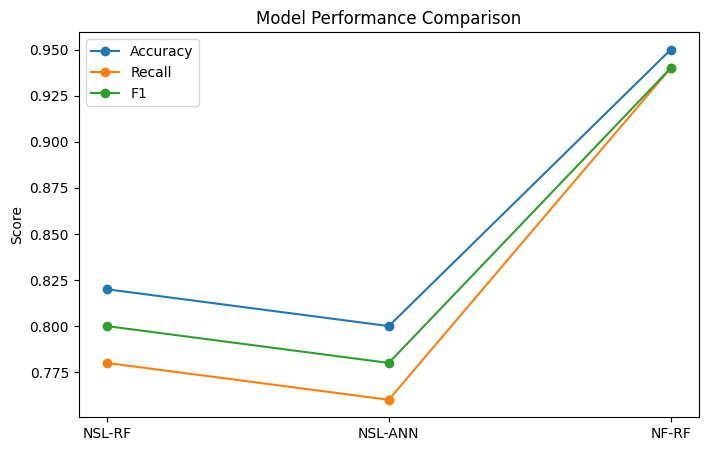

In [32]:
import matplotlib.pyplot as plt

models = ['NSL-RF','NSL-ANN','NF-RF']

accuracy = [0.82,0.80,0.95]
recall = [0.78,0.76,0.94]
f1 = [0.80,0.78,0.94]

plt.figure(figsize=(8,5))

plt.plot(models, accuracy, marker='o', label='Accuracy')
plt.plot(models, recall, marker='o', label='Recall')
plt.plot(models, f1, marker='o', label='F1')

plt.legend()

plt.title("Model Performance Comparison")
plt.ylabel("Score")

plt.show()

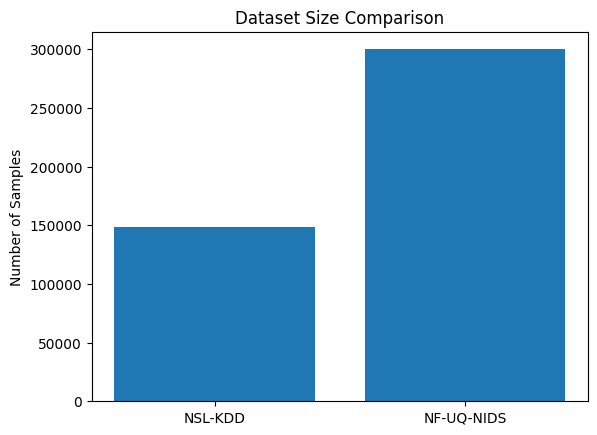

In [33]:
datasets = ['NSL-KDD','NF-UQ-NIDS']
samples = [148517,300000]

plt.bar(datasets,samples)

plt.title("Dataset Size Comparison")
plt.ylabel("Number of Samples")

plt.show()

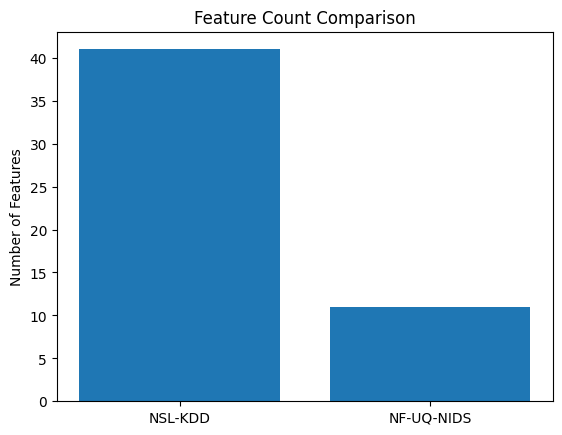

In [34]:
datasets = ['NSL-KDD','NF-UQ-NIDS']
features = [41,11]

plt.bar(datasets,features)

plt.title("Feature Count Comparison")
plt.ylabel("Number of Features")

plt.show()

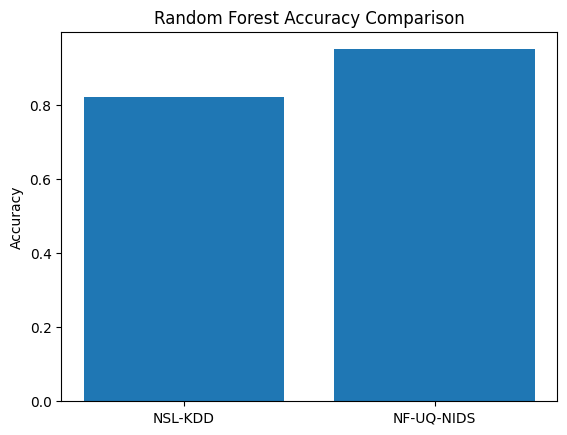

In [35]:
datasets = ['NSL-KDD','NF-UQ-NIDS']
accuracy = [0.82,0.95]

plt.bar(datasets,accuracy)

plt.title("Random Forest Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

In [37]:
# ==============================
# SAVE PREPROCESSOR + MODEL
# ==============================

import joblib

# 1. Save preprocessor
joblib.dump(preprocessor, "preprocessor.pkl")

# 2. Save trained model
joblib.dump(rf, "model.pkl")

print("✅ Preprocessor and Model saved successfully!")

✅ Preprocessor and Model saved successfully!
